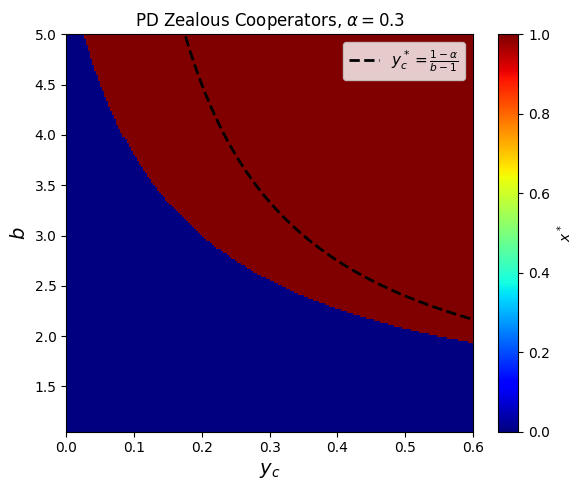

In [15]:
import numpy as np
import matplotlib.pyplot as plt

alpha = 0.3
n = 200
T, dt = 300, 0.1
steps = int(T / dt)

yc_arr = np.linspace(0.0, 0.6, n)
b_arr  = np.linspace(1.05, 5.0, n)
YC, B  = np.meshgrid(yc_arr, b_arr)

# Vectorize over ALL 200x200 = 40,000 points simultaneously
R_t = (B - 1) / (1 - alpha)
x = np.full_like(YC, 0.5)  # x0 = 0.5 everywhere

for _ in range(steps):
    NUM = (x + YC) * R_t - 1.0 - x * (B - 1)
    DEN = (x + YC) * R_t + (1 - x) * (B - 1)
    dx = np.where(np.abs(DEN) > 1e-12, (1 - x) * NUM / DEN, 0.0)
    x = np.clip(x + dt * dx, 1e-6, 1 - 1e-6)

# Plot
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.pcolormesh(YC, B, x, cmap='jet', vmin=0, vmax=1, shading='auto')

b_th = np.linspace(1.05, 5.0, 200)
ax.plot((1 - alpha) / (b_th - 1), b_th, 'k--', lw=2,
        label=r'$y_c^* = \frac{1-\alpha}{b-1}$')

ax.set_xlabel(r'$y_c$', fontsize=14)
ax.set_ylabel(r'$b$', fontsize=14)
ax.set_title(f'PD Zealous Cooperators, $\\alpha={alpha}$', fontsize=12)
ax.set_xlim(0, 0.6); ax.set_ylim(1.05, 5.0)
ax.legend(fontsize=11)
plt.colorbar(im, ax=ax, label=r'$x^*$')
plt.tight_layout()
plt.show()

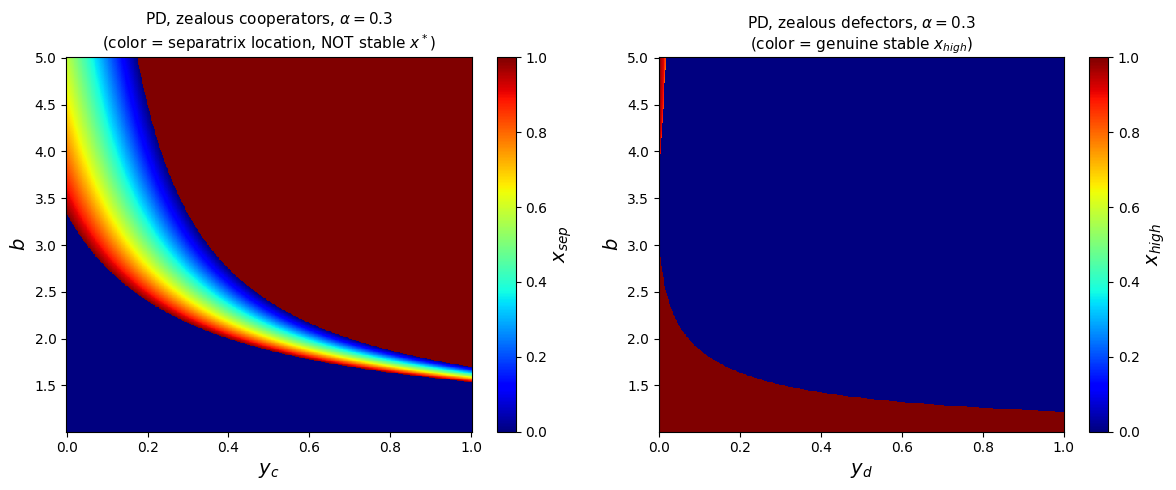

In [27]:
import numpy as np
import matplotlib.pyplot as plt

alpha = 0.3
n     = 500

y = np.linspace(0.0, 1.0, n)
b = np.linspace(1.01, 5.0, n)
Y, B = np.meshgrid(y, b)

R = (B - 1.0) / (1 - alpha)
S = -1.0
T = B
k = R - S - T   # >0 always for PD with alpha>0

# ---- Zealous Cooperators: linear -> separatrix (NOT stable eq) ----
A  = Y*R + S
Bn = (1 + Y)*R - T
xc = np.where((A > 0) & (Bn > 0), 1.0,
     np.where((A < 0) & (Bn < 0), 0.0,
              np.clip(-A/k, 0, 1)))

# ---- Zealous Defectors: quadratic -> x_high IS a genuine stable attractor ----
a1 = R - 2*S - T - Y*(S + T)
a0 = (1 + Y)*S
D  = a1**2 + 4*k*a0
ks = np.where(np.abs(k) < 1e-12, 1e-12, k)
xd = (a1 + np.sqrt(np.maximum(D, 0.0))) / (2*ks)
xd = np.where((D >= 0) & (xd > 0), np.clip(xd, 0, 1), 0.0)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

im0 = ax[0].pcolormesh(Y, B, xc, cmap='jet', shading='auto', vmin=0, vmax=1)
ax[0].set_xlabel(r'$y_c$', fontsize=14)
ax[0].set_ylabel(r'$b$', fontsize=14)
ax[0].set_title(rf'PD, zealous cooperators, $\alpha={alpha}$'
                '\n(color = separatrix location, NOT stable $x^*$)', fontsize=11)
cbar0 = fig.colorbar(im0, ax=ax[0])
cbar0.set_label(r'$x_{sep}$', fontsize=14)

im1 = ax[1].pcolormesh(Y, B, xd, cmap='jet', shading='auto', vmin=0, vmax=1)
ax[1].set_xlabel(r'$y_d$', fontsize=14)
ax[1].set_ylabel(r'$b$', fontsize=14)
ax[1].set_title(rf'PD, zealous defectors, $\alpha={alpha}$'
                '\n(color = genuine stable $x_{high}$)', fontsize=11)
cbar1 = fig.colorbar(im1, ax=ax[1])
cbar1.set_label(r'$x_{high}$', fontsize=14)

plt.tight_layout()
plt.show()

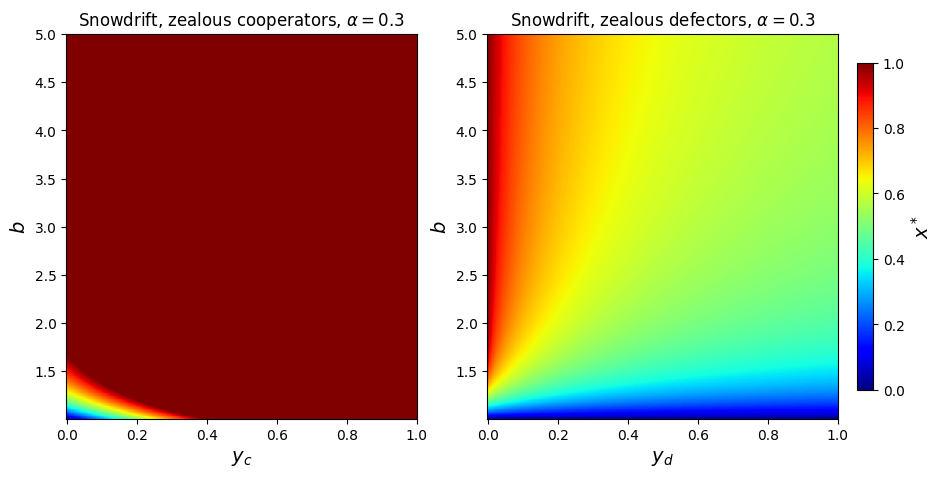

In [16]:
import numpy as np
import matplotlib.pyplot as plt

alpha = 0.3
n     = 500

y = np.linspace(0.0, 1.0, n)          # y_c  or  y_d
b = np.linspace(1.01, 5.0, n)
Y, B = np.meshgrid(y, b)

# Snowdrift effective payoffs
R = (B - 0.5) / (1 - alpha)
S = B - 1.0
T = B
k = R - S - T                          # <0 for alpha<1/2, >0 after

# ---------- zealous COOPERATORS : N(x) = A + k x  (linear) ----------
A = Y*R + S                            # N(0)
Bn = (1 + Y)*R - T                     # N(1)
xc = np.where((A > 0) & (Bn > 0), 1.0,          # cooperation dominant
     np.where((A < 0) & (Bn < 0), 0.0,          # defection dominant
              np.clip(-A/k, 0, 1)))             # interior root

# ---------- zealous DEFECTORS : N(x) = -k x^2 + a1 x + a0 ----------
a1 = R - 2*S - T - Y*(S + T)
a0 = (1 + Y)*S
D  = a1**2 + 4*k*a0
ks = np.where(np.abs(k) < 1e-12, 1e-12, k)
xd = (a1 + np.sqrt(np.maximum(D, 0.0))) / (2*ks)   # N'(x)= -sqrt(D) <= 0
xd = np.where((D >= 0) & (xd > 0), np.clip(xd, 0, 1), 0.0)

# ---------- plot ----------
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

for a, Z, lab in zip(ax, [xc, xd], [r'$y_c$', r'$y_d$']):
    im = a.pcolormesh(Y, B, Z, cmap='jet', shading='auto', vmin=0, vmax=1)
    a.set_xlabel(lab, fontsize=14)
    a.set_ylabel(r'$b$', fontsize=14)

ax[0].set_title(rf'Snowdrift, zealous cooperators, $\alpha={alpha}$', fontsize=12)
ax[1].set_title(rf'Snowdrift, zealous defectors, $\alpha={alpha}$',  fontsize=12)

cbar = fig.colorbar(im, ax=ax, shrink=0.85, pad=0.02)
cbar.set_label(r'$x^*$', fontsize=14)
plt.show()

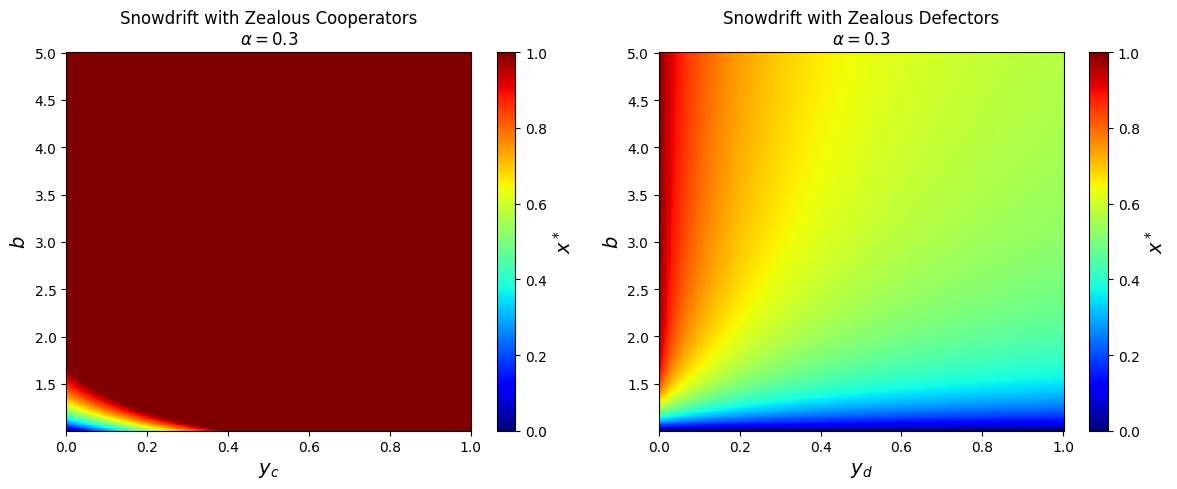

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# PARAMETERS
# ============================================================
alpha = 0.3

# ============================================================
# PANEL 1: ZEALOUS COOPERATORS (analytical formula - valid for
# Snowdrift since interior root is a STABLE attractor)
# ============================================================

yc = np.linspace(0.001, 1.0, 500)
b1 = np.linspace(1.01, 5.0, 500)
YC, B1 = np.meshgrid(yc, b1)

R_t1 = (B1 - 0.5) / (1 - alpha)
S_t1 = B1 - 1
T_t1 = B1

Xstar_C = (S_t1 + YC * R_t1) / (T_t1 + S_t1 - R_t1)
Xstar_C = np.clip(Xstar_C, 0, 1)


# ============================================================
# PANEL 2: ZEALOUS DEFECTORS (numerical integration - safer
# since the equilibrium condition is quadratic in x)
# ============================================================

def dxdt_Snowdrift_defectors(x, yd, b, alpha):
    R_t = (b - 0.5) / (1 - alpha)
    NUM = (1 - x) * x * R_t + (1 - x + yd) * ((b - 1) - x * (2*b - 1))
    DEN = x * R_t + (1 - x + yd) * (2*b - 1)
    return NUM / DEN

def simulate_grid(dxdt_func, Y_grid, P_grid, alpha, x0=0.5,
                   dt=0.05, steps=3000):
    X = np.full_like(Y_grid, x0, dtype=float)
    for _ in range(steps):
        dX = dxdt_func(X, Y_grid, P_grid, alpha)
        dX = np.nan_to_num(dX, nan=0.0, posinf=0.0, neginf=0.0)
        X = np.clip(X + dt * dX, 1e-6, 1 - 1e-6)
    return X

yd = np.linspace(0.001, 1.0, 300)
b2 = np.linspace(1.01, 5.0, 300)
YD, B2 = np.meshgrid(yd, b2)

Xstar_D = simulate_grid(dxdt_Snowdrift_defectors, YD, B2, alpha,
                        x0=0.5, dt=0.05, steps=3000)


# ============================================================
# PLOT BOTH SIDE BY SIDE
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Left: Zealous Cooperators ---
im1 = axes[0].pcolormesh(YC, B1, Xstar_C, cmap='jet',
                         shading='auto', vmin=0, vmax=1)
axes[0].set_xlabel(r'$y_c$', fontsize=14)
axes[0].set_ylabel(r'$b$', fontsize=14)
axes[0].set_title(f'Snowdrift with Zealous Cooperators\n$\\alpha={alpha}$',
                  fontsize=12)
cbar1 = plt.colorbar(im1, ax=axes[0])
cbar1.set_label(r'$x^*$', fontsize=14)

# --- Right: Zealous Defectors ---
im2 = axes[1].pcolormesh(YD, B2, Xstar_D, cmap='jet',
                         shading='auto', vmin=0, vmax=1)
axes[1].set_xlabel(r'$y_d$', fontsize=14)
axes[1].set_ylabel(r'$b$', fontsize=14)
axes[1].set_title(f'Snowdrift with Zealous Defectors\n$\\alpha={alpha}$',
                  fontsize=12)
cbar2 = plt.colorbar(im2, ax=axes[1])
cbar2.set_label(r'$x^*$', fontsize=14)

plt.tight_layout()
plt.savefig('Snowdrift_cooperators_vs_defectors.png', dpi=150)
plt.show()

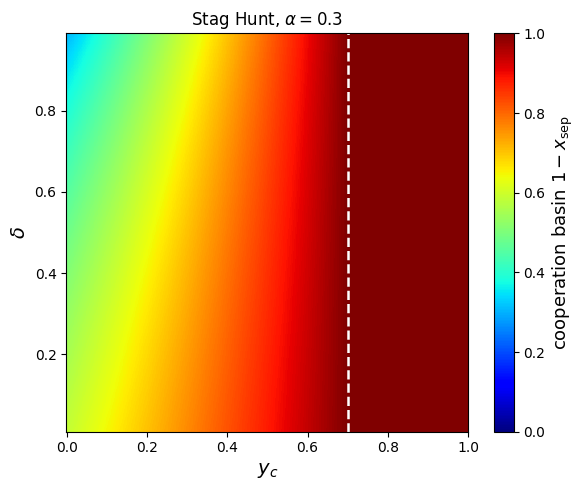

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
alpha = 0.3

# Axes
yc    = np.linspace(0.0, 1.0, 500)
delta = np.linspace(0.01, 0.99, 500)
YC, D = np.meshgrid(yc, delta)

# Effective payoffs (Stag Hunt: R=1, S=-1, T=delta, P=0)
R_t = 1 / (1 - alpha)
S_t = -1.0
T_t = D
P_t = 0.0

# Endpoint test:  N(x) = A + k x
A = YC * R_t + S_t - P_t          # N(0)
B = (1 + YC) * R_t - T_t          # N(1)
k = B - A

x_sep = -A / k                    # interior root

# Classify
X = np.where((A > 0) & (B > 0), 0.0,                 # coop dominant -> sep at 0
    np.where((A < 0) & (B < 0), 1.0,                 # defect dominant -> sep at 1
             np.clip(x_sep, 0, 1)))

basin = 1 - X                     # red = cooperation

# Plot
plt.figure(figsize=(6, 5))
im = plt.pcolormesh(YC, D, basin, cmap='jet',
                    shading='auto', vmin=0, vmax=1)

plt.axvline(1 - alpha, color='w', ls='--', lw=1.8)   # y_c = 1 - alpha

plt.xlabel(r'$y_c$', fontsize=14)
plt.ylabel(r'$\delta$', fontsize=14)
plt.title(rf'Stag Hunt, $\alpha={alpha}$', fontsize=12)

cbar = plt.colorbar(im)
cbar.set_label(r'cooperation basin $1-x_{\rm sep}$', fontsize=13)

plt.tight_layout()
plt.show()

coop  basin at y_c=0, delta=(0.05,0.5,0.95): [0.58, 0.481, 0.324]
  expected: [0.58, 0.481, 0.324]
def   x_high at y_d=0 (should be exactly 1.0): 0.0


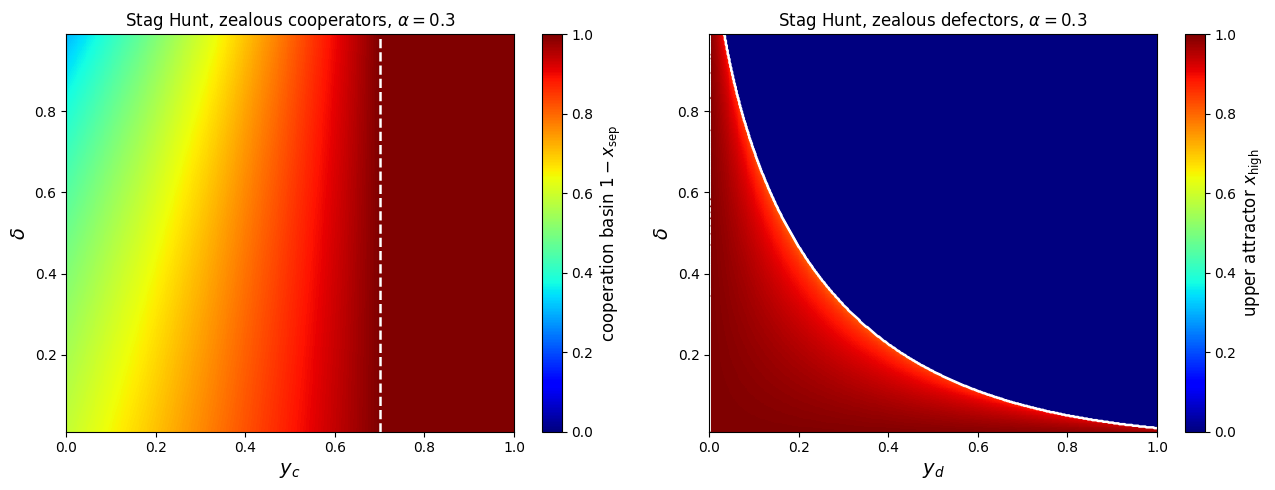

In [36]:
import numpy as np
import matplotlib.pyplot as plt

alpha = 0.3
n     = 500

y = np.linspace(0.0, 1.0, n)          # y_c  or  y_d
d = np.linspace(0.01, 0.99, n)
Y, D = np.meshgrid(y, d)

# Stag Hunt effective payoffs (R=1, S=-1, T=delta, P=0)
R = 1.0/(1 - alpha) + 0*D
S = -1.0 + 0*D
T = D
k = R - S - T                          # = 1/(1-a) + 1 - delta  > 0  ALWAYS

# ---------- zealous COOPERATORS ----------
# N(x) = A + k x   is linear;  N(1) = (1+y_c)R - delta > 0 always,
# so the only branch that can fire is the interior root.  No np.where needed.
x_sep = np.clip((-S - Y*R)/k, 0, 1)    # unstable separatrix
basin = 1 - x_sep                      # red = cooperation

# ---------- zealous DEFECTORS ----------
# N_D(x) = -k x^2 + a1 x + a0 ;  stable root is the '+sqrt' one
a1  = R - 2*S - T - Y*(S + T)
a0  = (1 + Y)*S                        # < 0  since S = -1
Dsc = a1**2 + 4*k*a0
xs  = (a1 + np.sqrt(np.maximum(Dsc, 0.0)))/(2*k)
xd  = np.where((Dsc >= 0) & (xs > 0) & (xs < 1), xs, 0.0)   # xs<1 guard is essential

# ---------- plot ----------
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

im0 = ax[0].pcolormesh(Y, D, basin, cmap='jet', shading='auto', vmin=0, vmax=1)
ax[0].axvline(1 - alpha, color='w', ls='--', lw=1.8)
ax[0].set_xlabel(r'$y_c$', fontsize=14)
ax[0].set_title(rf'Stag Hunt, zealous cooperators, $\alpha={alpha}$', fontsize=12)
fig.colorbar(im0, ax=ax[0]).set_label(r'cooperation basin $1-x_{\rm sep}$', fontsize=12)

im1 = ax[1].pcolormesh(Y, D, xd, cmap='jet', shading='auto', vmin=0, vmax=1)
ax[1].contour(Y, D, (xd > 0).astype(float), levels=[0.5],
              colors='w', linewidths=1.8)
ax[1].set_xlabel(r'$y_d$', fontsize=14)
ax[1].set_title(rf'Stag Hunt, zealous defectors, $\alpha={alpha}$', fontsize=12)
fig.colorbar(im1, ax=ax[1]).set_label(r'upper attractor $x_{\rm high}$', fontsize=12)

for a in ax:
    a.set_ylabel(r'$\delta$', fontsize=14)
    a.set_xlim(0, 1); a.set_ylim(0.01, 0.99)

# ---------- regression test ----------
Rv = 1/(1-alpha)
print("coop  basin at y_c=0, delta=(0.05,0.5,0.95):",
      [round(1 - 1/(Rv + 1 - dd), 3) for dd in (0.05, 0.5, 0.95)])
print("  expected: [0.58, 0.481, 0.324]")
print("def   x_high at y_d=0 (should be exactly 1.0):", round(xd[:, 0].min(), 4))

plt.tight_layout()
plt.show()

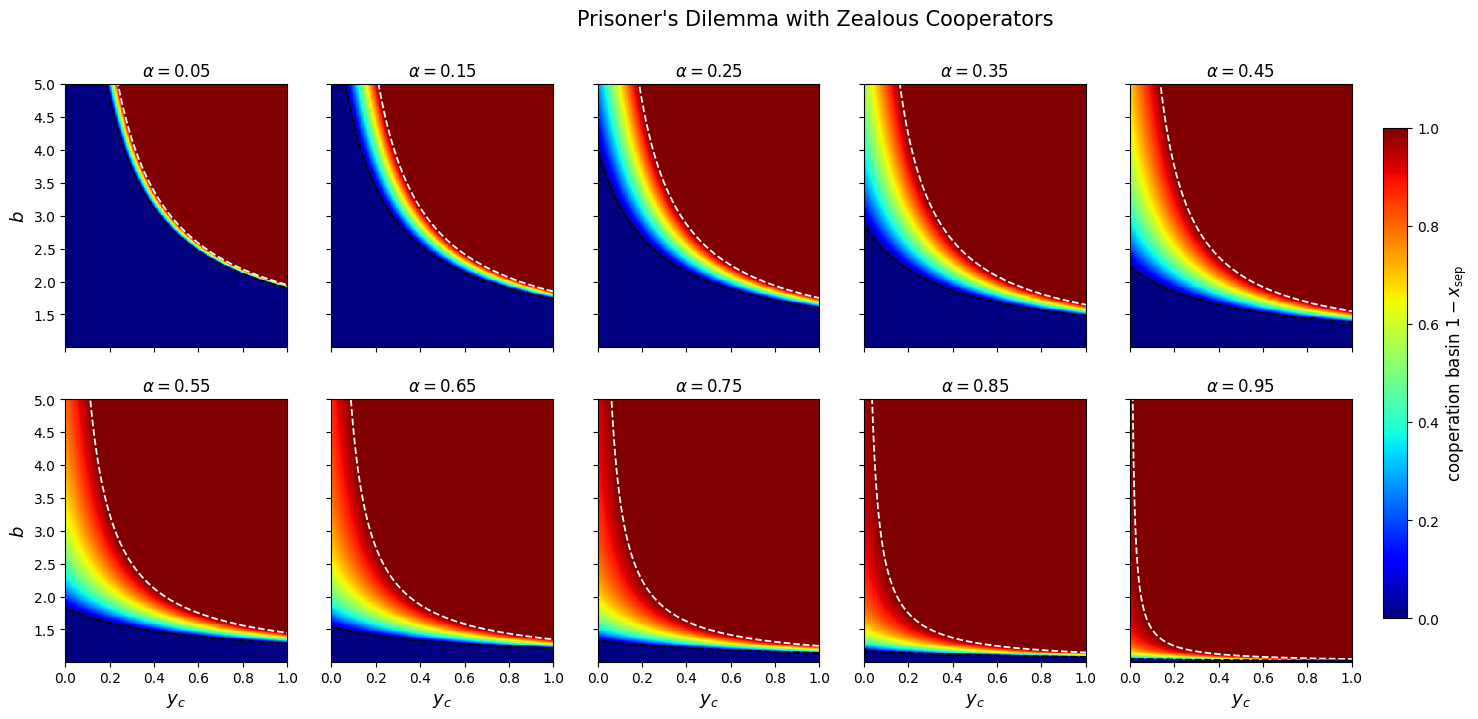

In [41]:
import numpy as np
import matplotlib.pyplot as plt

alphas = np.round(np.arange(0.05, 1.0, 0.1), 2)

yc = np.linspace(0.0, 1.0, 300)
b  = np.linspace(1.01, 5.0, 300)
YC, B_ = np.meshgrid(yc, b)

fig, axes = plt.subplots(2, 5, figsize=(20, 7.5), sharex=True, sharey=True)

for ax, a in zip(axes.ravel(), alphas):

    R_t, S_t, T_t, P_t = (B_ - 1)/(1 - a), -1.0, B_, 0.0

    A = YC*R_t + S_t - P_t              # N(0)
    B = (1 + YC)*R_t - T_t              # N(1)
    k = B - A

    x_sep = np.where((A > 0) & (B > 0), 0.0,
            np.where((A < 0) & (B < 0), 1.0,
                     np.clip(-A/k, 0, 1)))
    basin = 1 - x_sep                   # red = cooperation

    im = ax.pcolormesh(YC, B_, basin, cmap='jet',
                       shading='auto', vmin=0, vmax=1)

    bb = np.linspace(1.01, 5.0, 400)
    ax.plot((1-a)/(bb-1),     bb, 'w--', lw=1.3)   # coop dominant
    ax.plot((1-a)/(bb-1) - a, bb, 'k--', lw=1.3)   # defect dominant

    ax.set_xlim(0, 1); ax.set_ylim(1.01, 5.0)
    ax.set_title(rf'$\alpha={a}$', fontsize=12)

for ax in axes[1, :]: ax.set_xlabel(r'$y_c$', fontsize=13)
for ax in axes[:, 0]: ax.set_ylabel(r'$b$', fontsize=13)

cbar = fig.colorbar(im, ax=axes, shrink=0.85, pad=0.02)
cbar.set_label(r'cooperation basin $1-x_{\rm sep}$', fontsize=12)
fig.suptitle("Prisoner's Dilemma with Zealous Cooperators", fontsize=15)
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_19640\1165130841.py:20: RuntimeWarning: divide by zero encountered in divide
  xstar = (S_t + YC * R_t) / (S_t + T_t - R_t)


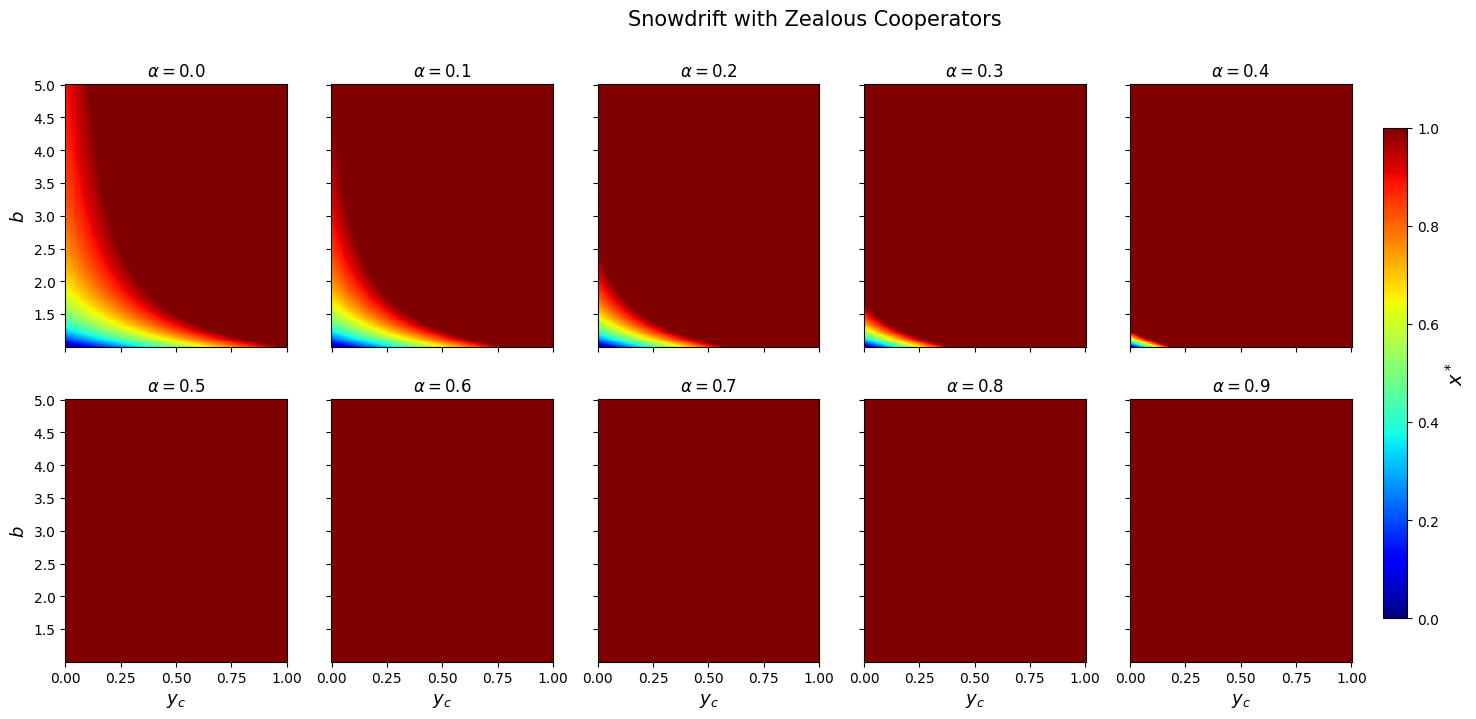

In [42]:
import numpy as np
import matplotlib.pyplot as plt

alphas = np.round(np.arange(0.0, 1.0, 0.1), 1)   # 10 values: 0.0 ... 0.9

yc = np.linspace(0.001, 1.0, 300)
b  = np.linspace(1.01, 5.0, 300)
YC, B = np.meshgrid(yc, b)

fig, axes = plt.subplots(2, 5, figsize=(20, 7.5), sharex=True, sharey=True)

for ax, a in zip(axes.ravel(), alphas):

    # Effective payoffs (Snowdrift: R=b-0.5, S=b-1, T=b, P=0)
    R_t = (B - 0.5) / (1 - a)
    S_t = B - 1
    T_t = B

    k     = R_t - (S_t + T_t)                 # slope of dx/dt
    xstar = (S_t + YC * R_t) / (S_t + T_t - R_t)

    # k > 0  -> cooperation dominant (x* is unstable / outside) -> x = 1
    # k < 0  -> stable interior root
    X = np.where(k > 0, 1.0, np.clip(xstar, 0, 1))

    im = ax.pcolormesh(YC, B, X, cmap='jet', shading='auto', vmin=0, vmax=1)
    ax.set_title(rf'$\alpha={a}$', fontsize=12)

for ax in axes[1, :]:
    ax.set_xlabel(r'$y_c$', fontsize=13)
for ax in axes[:, 0]:
    ax.set_ylabel(r'$b$', fontsize=13)

cbar = fig.colorbar(im, ax=axes, shrink=0.85, pad=0.02)
cbar.set_label(r'$x^*$', fontsize=14)

fig.suptitle('Snowdrift with Zealous Cooperators', fontsize=15)
plt.show()

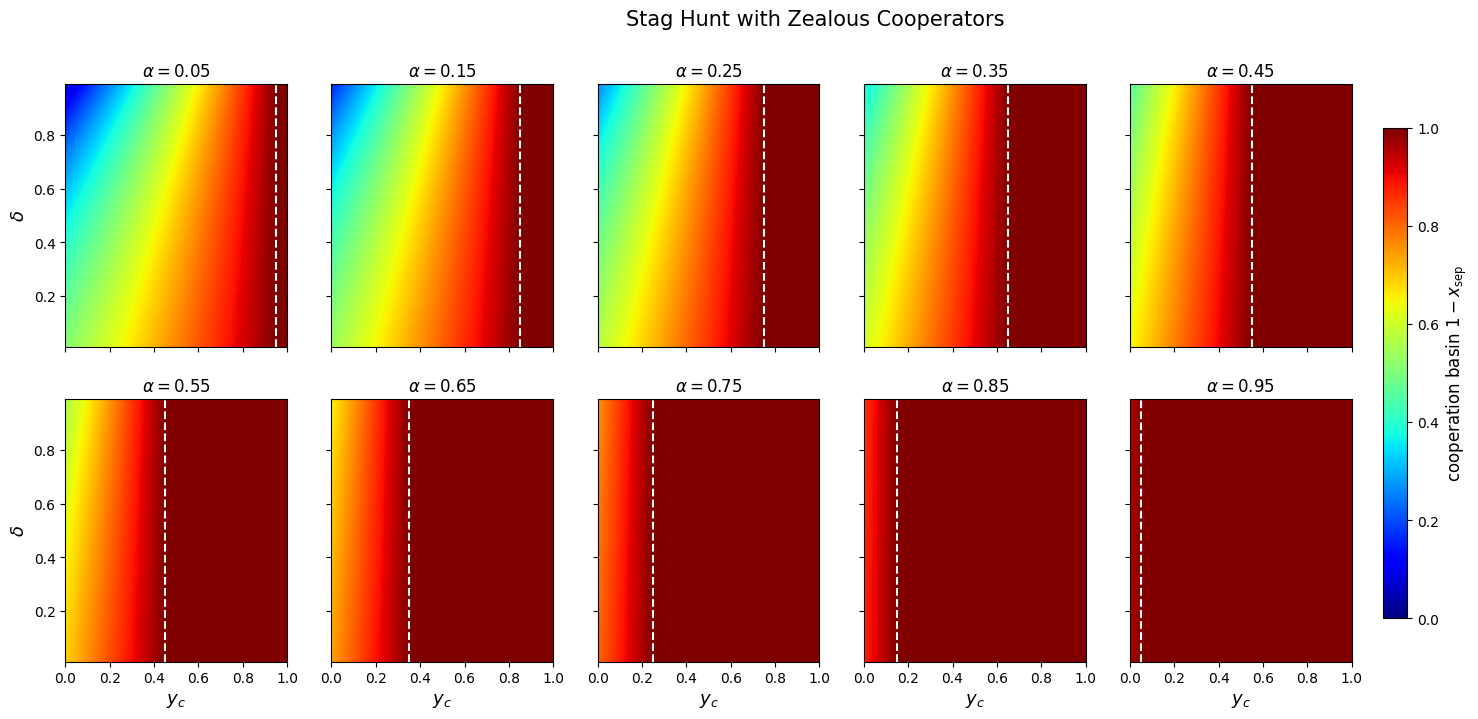

In [43]:
import numpy as np
import matplotlib.pyplot as plt

alphas = np.round(np.arange(0.05, 1.0, 0.1), 2)   # 0.05 ... 0.95

yc    = np.linspace(0.0, 1.0, 300)
delta = np.linspace(0.01, 0.99, 300)
YC, D = np.meshgrid(yc, delta)

fig, axes = plt.subplots(2, 5, figsize=(20, 7.5), sharex=True, sharey=True)

for ax, a in zip(axes.ravel(), alphas):

    R_t = 1.0 / (1 - a)
    S_t = -1.0
    T_t = D

    k     = R_t - (S_t + T_t)                  # > 0 always -> unstable root
    xsep  = np.clip((-S_t - YC * R_t) / k, 0, 1)
    basin = 1 - xsep                           # red = cooperation

    im = ax.pcolormesh(YC, D, basin, cmap='jet',
                       shading='auto', vmin=0, vmax=1)

    ax.axvline(1 - a, color='w', ls='--', lw=1.5)   # coop-dominant threshold
    ax.set_xlim(0, 1); ax.set_ylim(0.01, 0.99)
    ax.set_title(rf'$\alpha={a}$', fontsize=12)

for ax in axes[1, :]: ax.set_xlabel(r'$y_c$', fontsize=13)
for ax in axes[:, 0]: ax.set_ylabel(r'$\delta$', fontsize=13)

cbar = fig.colorbar(im, ax=axes, shrink=0.85, pad=0.02)
cbar.set_label(r'cooperation basin $1-x_{\rm sep}$', fontsize=12)
fig.suptitle('Stag Hunt with Zealous Cooperators', fontsize=15)
plt.show()

PRISONER'S DILEMMA - Zealous Defectors
  Prisoner's Dilemma: alpha=0.05 ... done
  Prisoner's Dilemma: alpha=0.15 ... done
  Prisoner's Dilemma: alpha=0.25 ... done
  Prisoner's Dilemma: alpha=0.35 ... done
  Prisoner's Dilemma: alpha=0.45 ... done
  Prisoner's Dilemma: alpha=0.55 ... done
  Prisoner's Dilemma: alpha=0.65 ... done
  Prisoner's Dilemma: alpha=0.75 ... done
  Prisoner's Dilemma: alpha=0.85 ... done
  Prisoner's Dilemma: alpha=0.95 ... done


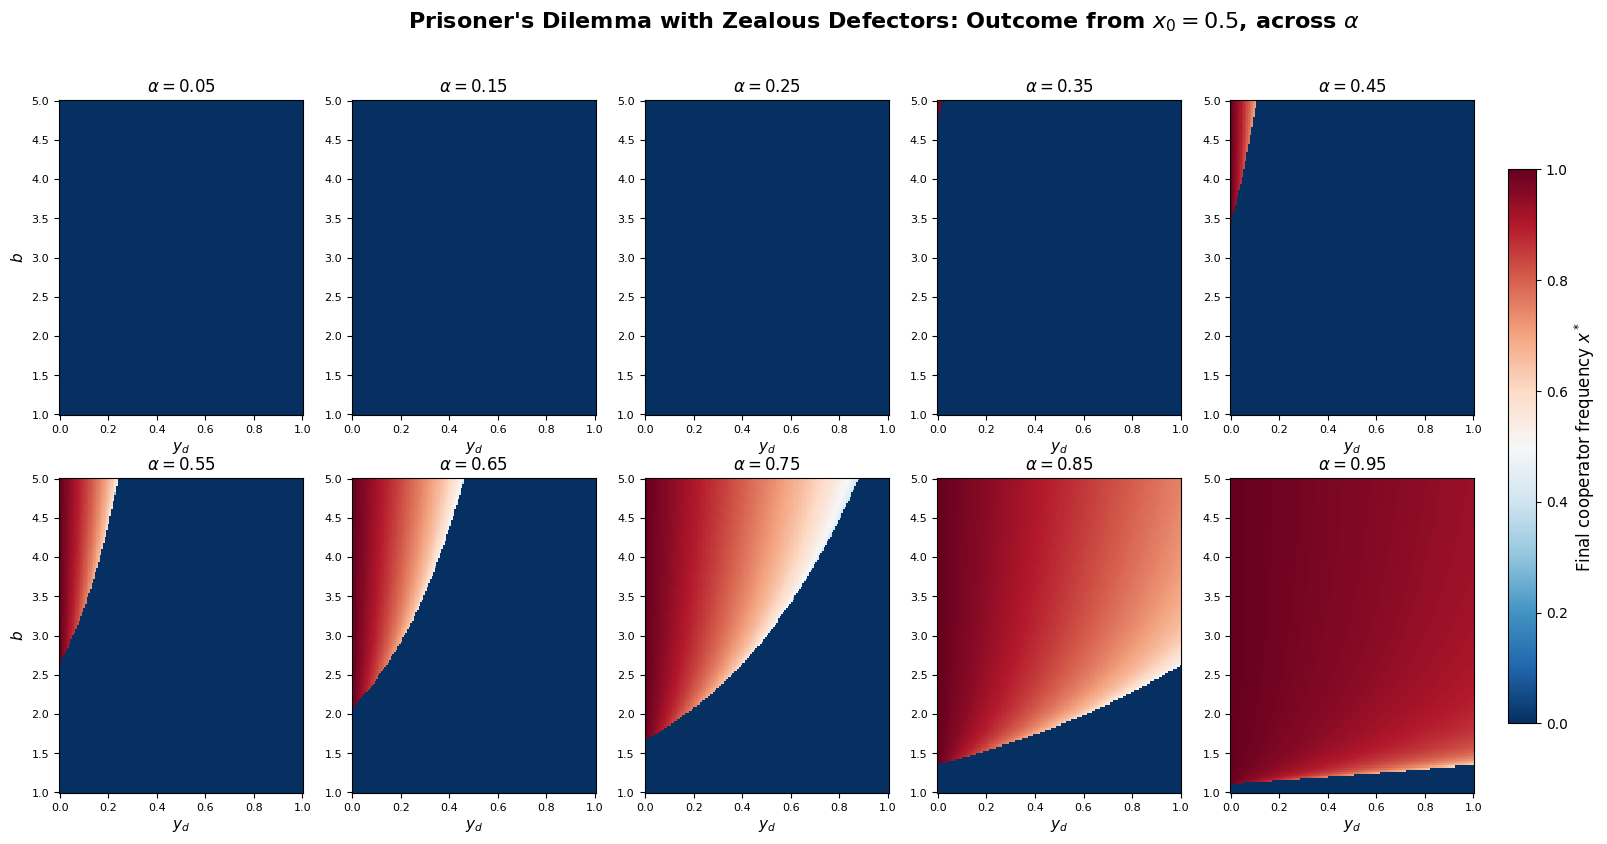


SNOWDRIFT - Zealous Defectors
  Snowdrift: alpha=0.05 ... done
  Snowdrift: alpha=0.15 ... done
  Snowdrift: alpha=0.25 ... done
  Snowdrift: alpha=0.35 ... done
  Snowdrift: alpha=0.45 ... done
  Snowdrift: alpha=0.55 ... done
  Snowdrift: alpha=0.65 ... done
  Snowdrift: alpha=0.75 ... done
  Snowdrift: alpha=0.85 ... done
  Snowdrift: alpha=0.95 ... done


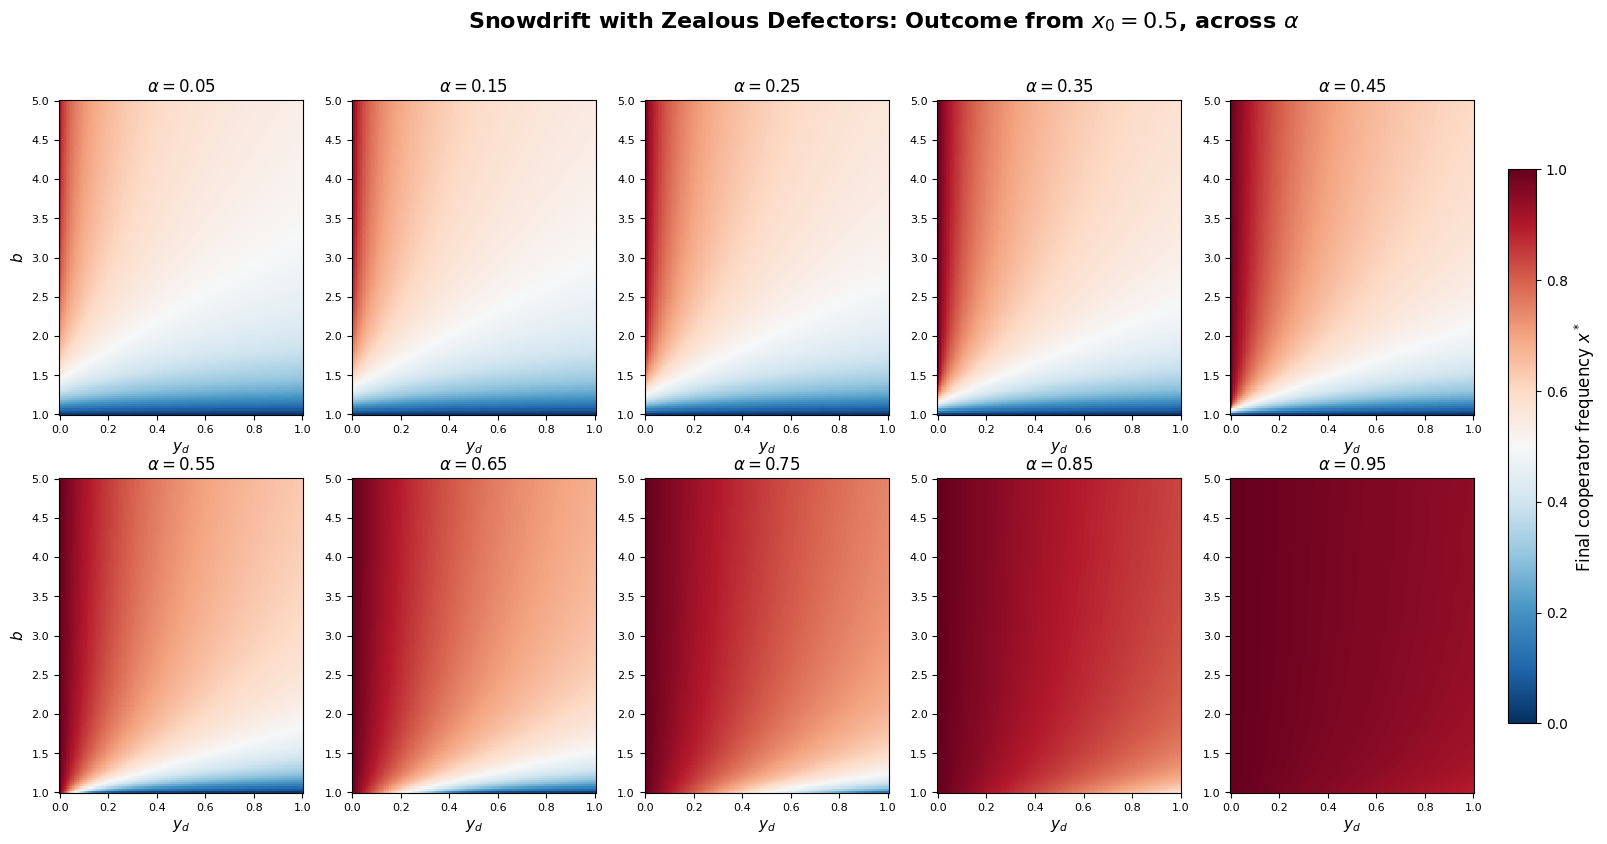


STAG HUNT - Zealous Defectors
  Stag Hunt: alpha=0.05 ... done
  Stag Hunt: alpha=0.15 ... done
  Stag Hunt: alpha=0.25 ... done
  Stag Hunt: alpha=0.35 ... done
  Stag Hunt: alpha=0.45 ... done
  Stag Hunt: alpha=0.55 ... done
  Stag Hunt: alpha=0.65 ... done
  Stag Hunt: alpha=0.75 ... done
  Stag Hunt: alpha=0.85 ... done
  Stag Hunt: alpha=0.95 ... done


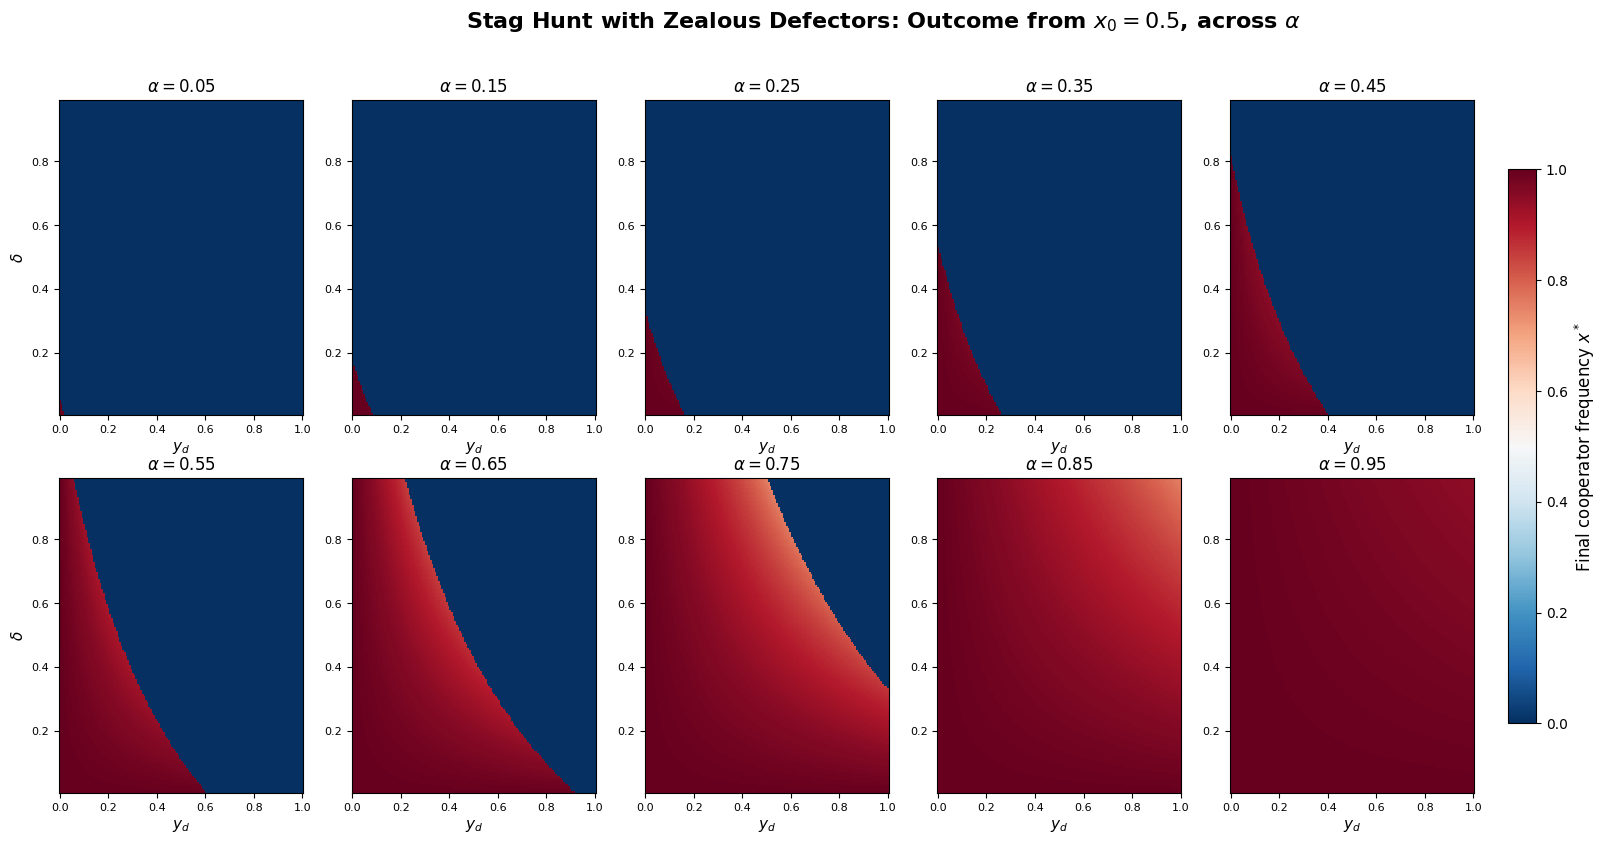

In [44]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# ZEALOUS DEFECTOR DYNAMICS (dx/dt) FOR EACH GAME
# ============================================================

def dxdt_PD_defectors(x, yd, b, alpha):
    R_t = (b - 1) / (1 - alpha)
    NUM = (1 - x) * x * R_t + (1 - x + yd) * (-1 - x * (b - 1))
    DEN = x * R_t + (1 - x + yd) * (b - 1)
    return NUM / DEN   # DEN always > 0 for PD (b-1>0)

def dxdt_Snowdrift_defectors(x, yd, b, alpha):
    R_t = (b - 0.5) / (1 - alpha)
    NUM = (1 - x) * x * R_t + (1 - x + yd) * ((b - 1) - x * (2*b - 1))
    DEN = x * R_t + (1 - x + yd) * (2*b - 1)
    return NUM / DEN   # DEN always > 0 for Snowdrift (2b-1>0)

def dxdt_StagHunt_defectors(x, yd, delta, alpha):
    R_t = 1 / (1 - alpha)
    # UNNORMALIZED (denominator can vanish since delta-1 < 0)
    NUM = (1 - x) * x * R_t + (1 - x + yd) * (-1 + x * (1 - delta))
    return NUM


# ============================================================
# VECTORIZED EULER INTEGRATION OVER ENTIRE GRID SIMULTANEOUSLY
# ============================================================

def simulate_grid(dxdt_func, Y_grid, P_grid, alpha, x0=0.5,
                   dt=0.05, steps=3000):
    """
    Integrate dx/dt for every (Y,P) grid point simultaneously.
    Y_grid: yd values (meshgrid)
    P_grid: b or delta values (meshgrid)
    Returns final x array (same shape as Y_grid)
    """
    X = np.full_like(Y_grid, x0, dtype=float)
    for _ in range(steps):
        dX = dxdt_func(X, Y_grid, P_grid, alpha)
        dX = np.nan_to_num(dX, nan=0.0, posinf=0.0, neginf=0.0)
        X = np.clip(X + dt * dX, 1e-6, 1 - 1e-6)
    return X


# ============================================================
# MAKE 10-ALPHA GRID FIGURE FOR A GIVEN GAME
# ============================================================

def make_alpha_grid(dxdt_func, param_range, param_label, game_name,
                     x0=0.5, n=150, alpha_values=None,
                     dt=0.05, steps=2500, save_name='grid.png'):

    if alpha_values is None:
        alpha_values = np.linspace(0.05, 0.95, 10)

    yd_arr = np.linspace(0.001, 1.0, n)
    p_arr  = np.linspace(*param_range, n)
    YD, P = np.meshgrid(yd_arr, p_arr)

    fig, axes = plt.subplots(2, 5, figsize=(22, 9))
    fig.suptitle(f'{game_name} with Zealous Defectors: '
                 f'Outcome from $x_0={x0}$, across $\\alpha$',
                 fontsize=16, fontweight='bold')
    axes_flat = axes.flatten()

    for i, alpha in enumerate(alpha_values):
        ax = axes_flat[i]
        print(f"  {game_name}: alpha={alpha:.2f} ...", end=' ', flush=True)

        Xfinal = simulate_grid(dxdt_func, YD, P, alpha,
                               x0=x0, dt=dt, steps=steps)

        im = ax.pcolormesh(YD, P, Xfinal, cmap='RdBu_r',
                           shading='auto', vmin=0, vmax=1)
        ax.set_title(f'$\\alpha = {alpha:.2f}$', fontsize=12)
        ax.set_xlabel(r'$y_d$', fontsize=11)
        if i % 5 == 0:
            ax.set_ylabel(param_label, fontsize=11)
        ax.tick_params(labelsize=8)
        print("done")

    cbar = fig.colorbar(im, ax=axes, shrink=0.8, pad=0.02)
    cbar.set_label('Final cooperator frequency $x^*$', fontsize=12)

    plt.savefig(save_name, dpi=150, bbox_inches='tight')
    plt.show()


# ============================================================
# RUN FOR ALL THREE GAMES
# ============================================================

if __name__ == '__main__':

    x0 = 0.5   # starting cooperator frequency

    print("=" * 55)
    print("PRISONER'S DILEMMA - Zealous Defectors")
    print("=" * 55)
    make_alpha_grid(
        dxdt_func=dxdt_PD_defectors,
        param_range=(1.01, 5.0),
        param_label=r'$b$',
        game_name="Prisoner's Dilemma",
        x0=x0,
        save_name='PD_defectors_grid.png'
    )

    print("\n" + "=" * 55)
    print("SNOWDRIFT - Zealous Defectors")
    print("=" * 55)
    make_alpha_grid(
        dxdt_func=dxdt_Snowdrift_defectors,
        param_range=(1.01, 5.0),
        param_label=r'$b$',
        game_name="Snowdrift",
        x0=x0,
        save_name='Snowdrift_defectors_grid.png'
    )

    print("\n" + "=" * 55)
    print("STAG HUNT - Zealous Defectors")
    print("=" * 55)
    make_alpha_grid(
        dxdt_func=dxdt_StagHunt_defectors,
        param_range=(0.01, 0.99),
        param_label=r'$\delta$',
        game_name="Stag Hunt",
        x0=x0,
        save_name='StagHunt_defectors_grid.png'
    )